In [1]:
import sys
sys.path.insert(0, "..")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from wko5.pdcurve import compute_envelope_mmp, fit_pd_model, rolling_ftp, power_at_durations, _pd_model
from wko5.db import WEIGHT_KG
%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')

## MMP Curve (90 days)

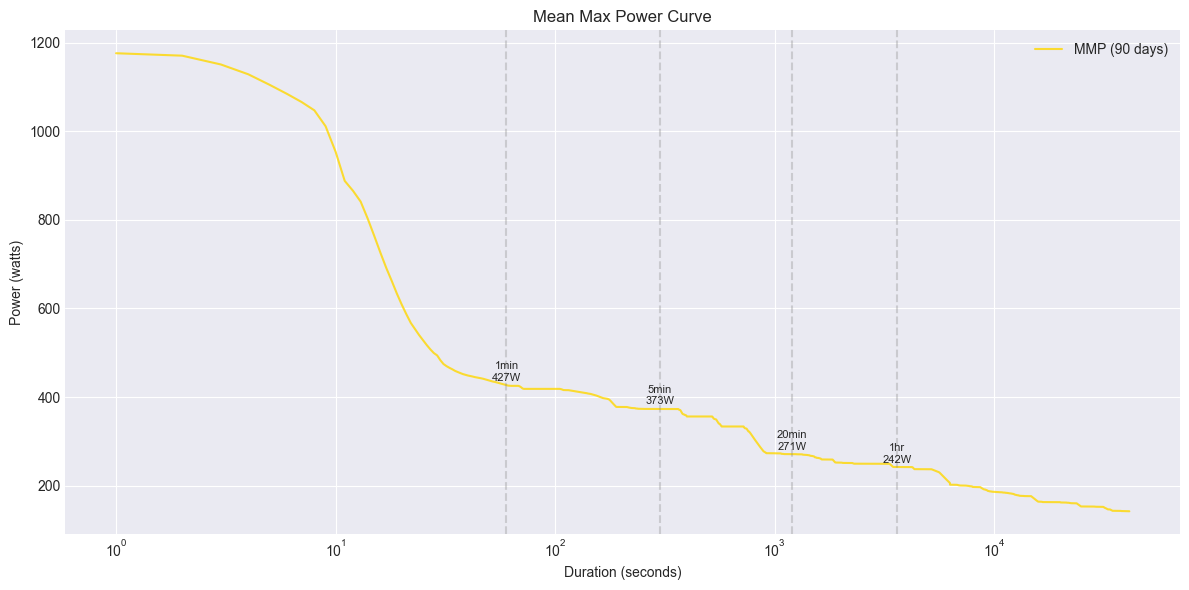

In [2]:
mmp = compute_envelope_mmp(days=90)
durations = np.arange(1, len(mmp) + 1)
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(durations, mmp, color='gold', alpha=0.8, label='MMP (90 days)')
ax.set_xscale('log')
ax.set_xlabel('Duration (seconds)')
ax.set_ylabel('Power (watts)')
ax.set_title('Mean Max Power Curve')
ax.legend()
for t, label in [(60, '1min'), (300, '5min'), (1200, '20min'), (3600, '1hr')]:
    if t < len(mmp):
        ax.axvline(t, color='gray', linestyle='--', alpha=0.3)
        ax.text(t, mmp[t-1]+10, f'{label}\n{mmp[t-1]:.0f}W', fontsize=8, ha='center')
plt.tight_layout()
plt.show()

## PD Model Fit

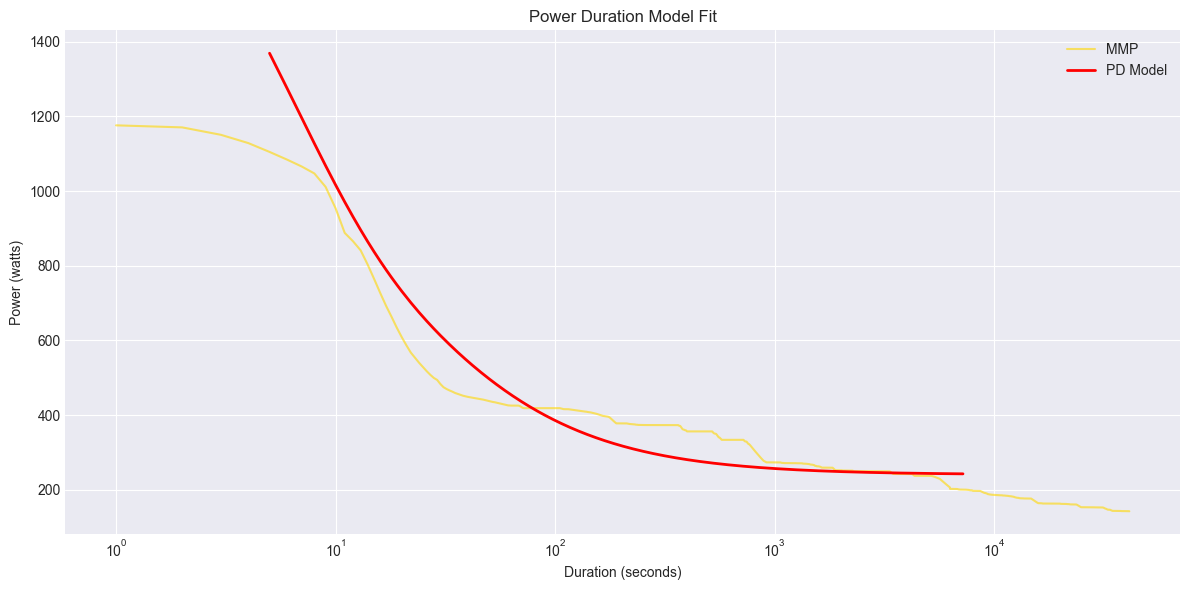

Pmax: 800.0W | FRC: 16.69 kJ | mFTP: 240.3W
TTE: 120.0 min | VO2max: 41.5 mL/min/kg


In [3]:
model = fit_pd_model(mmp)
if model:
    t_model = np.arange(5, min(len(mmp), 7200) + 1, dtype=float)
    p_model = _pd_model(t_model, model['Pmax'], model['tau'], model['FRC'], model['t0'], model['mFTP'])
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(durations, mmp, color='gold', alpha=0.6, label='MMP')
    ax.plot(t_model, p_model, color='red', linewidth=2, label='PD Model')
    ax.set_xscale('log')
    ax.set_xlabel('Duration (seconds)')
    ax.set_ylabel('Power (watts)')
    ax.set_title('Power Duration Model Fit')
    ax.legend()
    plt.tight_layout()
    plt.show()
    print(f"Pmax: {model['Pmax']}W | FRC: {model['FRC']} kJ | mFTP: {model['mFTP']}W")
    print(f"TTE: {model['TTE']} min | VO2max: {model['mVO2max_ml_min_kg']} mL/min/kg")

## Rolling FTP

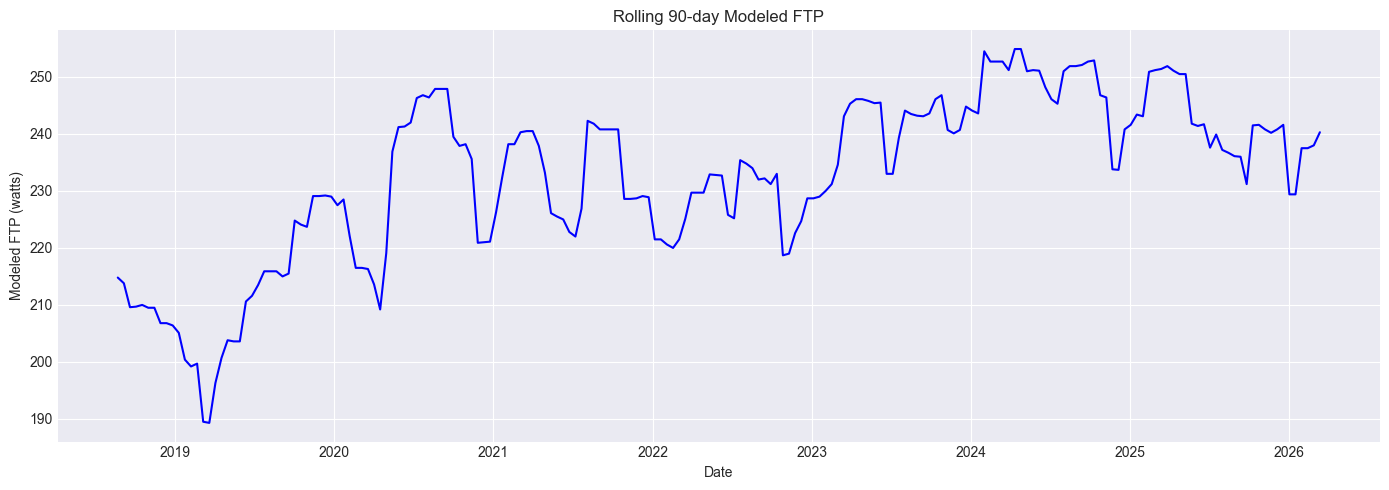

In [5]:
ftp_trend = rolling_ftp(window_days=90, step_days=14)
if not ftp_trend.empty:
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(pd.to_datetime(ftp_trend['date']), ftp_trend['mFTP'], color='blue', linewidth=1.5)
    ax.set_xlabel('Date')
    ax.set_ylabel('Modeled FTP (watts)')
    ax.set_title('Rolling 90-day Modeled FTP')
    plt.tight_layout()
    plt.show()

## Period Comparison

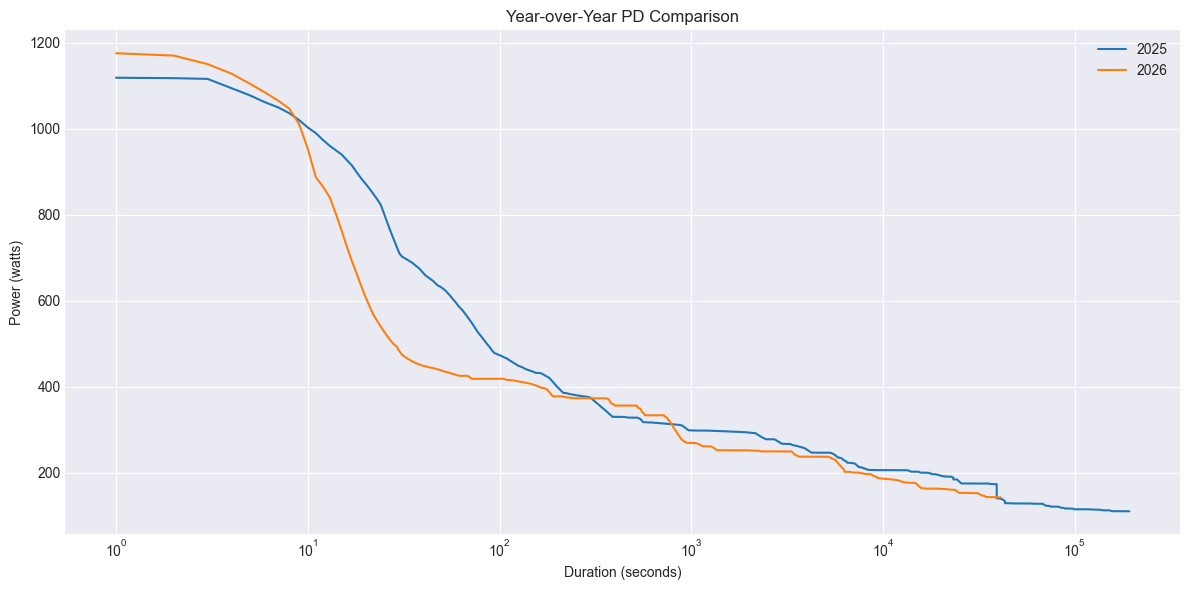

In [6]:
from wko5.pdcurve import compare_periods
comparison = compare_periods(('2025-01-01', '2025-12-31'), ('2026-01-01', '2026-12-31'))
fig, ax = plt.subplots(figsize=(12, 6))
for label, data in [('2025', comparison['period1']), ('2026', comparison['period2'])]:
    m = data['mmp']
    if len(m) > 0:
        ax.plot(np.arange(1, len(m)+1), m, label=label)
ax.set_xscale('log')
ax.set_xlabel('Duration (seconds)')
ax.set_ylabel('Power (watts)')
ax.set_title('Year-over-Year PD Comparison')
ax.legend()
plt.tight_layout()
plt.show()